# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Єдинець Євген'
ГРУПА = 'ШІ-31'
ВАРІАНТ = 6

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30


In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 6 · Єдинець Євген, ШІ-31, «Longer Boats»
Підприємство «Longer Boats» виготовляє яхти. Одиниця виміру плану: шт./місяць.

                       Sting  Ray  Breaker  Marlin  ЗАПАС
Склопластик, м²            3    2        1       4    630
Столярний цех, год         4    2        2       1    391
Фарбувальний цех, год      3    5        1       2   1349
Такелаж, компл.            3    2        0       2    811
Ділянка добудови, год      6    4        6       3   1085

                    Sting  Ray  Breaker  Marlin
Прибуток з одиниці     40   62       19      57

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Столярний цех, год
  ціна:   29.5 за одиницю
  обсяг:  до 268 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

pulp не встановлено — скористайтеся scipy.optimize.linprog


---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1.**

Нехай $x_1,x_2,x_3,x_4$ — кількість яхт Sting, Ray, Breaker і Marlin за місяць.

$$\max Z=40x_1+62x_2+19x_3+57x_4$$

Обмеження:
$$
\begin{aligned}
3x_1+2x_2+x_3+4x_4&\le630\\
4x_1+2x_2+2x_3+x_4&\le391\\
3x_1+5x_2+x_3+2x_4&\le1349\\
3x_1+2x_2+2x_4&\le811\\
6x_1+4x_2+6x_3+3x_4&\le1085
\end{aligned}
$$

$$x_1,x_2,x_3,x_4\ge0$$


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2.** Запас ресурсу є параметром, тому що він відомий ще до вибору плану виробництва. Змінними є кількості виробів, які ми вирішуємо виготовляти. Якщо ресурс можна докуповувати, можна додати змінну $q_i\ge0$ і записати обмеження як $Ax\le b+q$, а в цільовій функції відняти вартість закупівлі.


---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
EXCEL_ПЛАН = [0.0, 155.66666666666666, 0.0, 79.66666666666669]
EXCEL_ПРИБУТОК = 14192.333333333332

print('Excel:', EXCEL_ПЛАН, '| прибуток:', EXCEL_ПРИБУТОК)


Excel: [0.0, 155.66666666666666, 0.0, 79.66666666666669] | прибуток: 14192.333333333332


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
v = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]

A = np.array(v['A'], dtype=float)
b = np.array(v['b'], dtype=float)
c = np.array(v['c'], dtype=float)

res = linprog(
    -c,
    A_ub=A,
    b_ub=b,
    bounds=(0, None),
    method='highs'
)

assert res.success, res.message

план = res.x
прибуток = -res.fun

print(pd.DataFrame({
    'Виріб': v['вироби'],
    'План': план,
    'Прибуток з одиниці': c
}).to_string(index=False))

print('Прибуток:', прибуток)
print('Використано ресурсів:', A @ план)
print('Залишки:', b - A @ план)


  Виріб       План  Прибуток з одиниці
  Sting   0.000000                40.0
    Ray 155.666667                62.0
Breaker   0.000000                19.0
 Marlin  79.666667                57.0
Прибуток: 14192.333333333332
Використано ресурсів: [630.         391.         937.66666667 470.66666667 861.66666667]
Залишки: [  0.           0.         411.33333333 340.33333333 223.33333333]


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

**Відповідь 4.1.**

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---:|---:|---:|---:|---:|
| Склопластик, м² | 630 | 8.666667 | 630 | 670 | 239 |
| Столярний цех, год | 391 | 22.333333 | 391 | 134 | 233.5 |
| Фарбувальний цех, год | 937.666667 | 0 | 1349 | ∞ | 411.333333 |
| Такелаж, компл. | 470.666667 | 0 | 811 | ∞ | 340.333333 |
| Ділянка добудови, год | 861.666667 | 0 | 1085 | ∞ | 223.333333 |

Дефіцитні ресурси — склопластик і столярний цех: вони використані повністю, а їх тіньові ціни більші за нуль. Для інших ресурсів є залишок, тому їх тіньова ціна дорівнює нулю.


### Завдання 4.2 — блок «Змінні»

**Відповідь 4.2.**

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---:|---:|---:|---:|---:|
| Sting | 0 | -75.333333 | 40 | 75.333333 | ∞ |
| Ray | 155.666667 | 0 | 62 | 52 | 29.428571 |
| Breaker | 0 | -34.333333 | 19 | 34.333333 | ∞ |
| Marlin | 79.666667 | 0 | 57 | 67 | 26 |

Не виробляються Sting і Breaker. Для Sting прибуток з одиниці має зрости на 75.33, а для Breaker — на 34.33. Це модулі їх зведених вартостей.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [7]:
тіньові = -res.ineqlin.marginals
ресурс_найцінніший = int(np.argmax(тіньові))

b_new = b.copy()
b_new[ресурс_найцінніший] += 1

res_plus = linprog(
    -c,
    A_ub=A,
    b_ub=b_new,
    bounds=(0, None),
    method='highs'
)

assert res_plus.success

приріст_1 = -res_plus.fun - прибуток

print('Ресурс:', v['ресурси'][ресурс_найцінніший])
print('Приріст прибутку:', приріст_1)
print('Тіньова ціна:', тіньові[ресурс_найцінніший])

assert np.isclose(приріст_1, тіньові[ресурс_найцінніший])


Ресурс: Столярний цех, год
Приріст прибутку: 22.33333333333576
Тіньова ціна: 22.333333333333336


**Відповідь 5.1.** Для столярного цеху збільшив запас з 391 до 392 год. Прибуток зріс з 14192.33 до 14214.67, тобто на **22.33**. Це збігається з тіньовою ціною.


### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

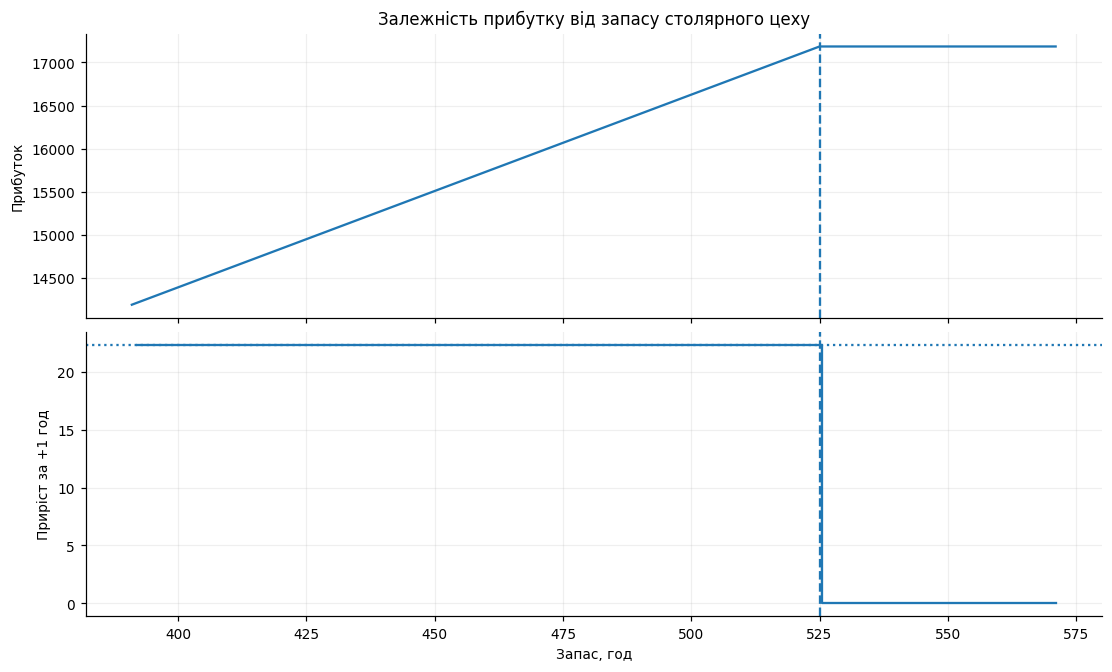

Межа: 525
Допустиме збільшення: 134


In [8]:
початковий_запас = int(b[ресурс_найцінніший])
запаси_скан = np.arange(початковий_запас, початковий_запас + 181)

прибутки_скан = []

for запас_ресурсу in запаси_скан:
    b_test = b.copy()
    b_test[ресурс_найцінніший] = запас_ресурсу

    test_res = linprog(
        -c,
        A_ub=A,
        b_ub=b_test,
        bounds=(0, None),
        method='highs'
    )

    assert test_res.success
    прибутки_скан.append(-test_res.fun)

прибутки_скан = np.array(прибутки_скан)
прирости = np.diff(прибутки_скан)

зміни = np.where(~np.isclose(прирости, тіньові[ресурс_найцінніший]))[0]
межа_дельта = int(зміни[0])

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout='constrained')

axes[0].plot(запаси_скан, прибутки_скан)
axes[0].set_ylabel('Прибуток')
axes[0].set_title('Залежність прибутку від запасу столярного цеху')

axes[1].step(запаси_скан[1:], прирости, where='mid')
axes[1].axhline(тіньові[ресурс_найцінніший], linestyle=':')
axes[1].set_xlabel('Запас, год')
axes[1].set_ylabel('Приріст за +1 год')

for ax in axes:
    ax.axvline(початковий_запас + межа_дельта, linestyle='--')
    ax.grid(alpha=0.2)

plt.show()

print('Межа:', початковий_запас + межа_дельта)
print('Допустиме збільшення:', межа_дельта)

assert межа_дельта == 134


**Відповідь 5.2.** До запасу **525 год** приріст прибутку за додаткову годину залишається 22.33. Отже допустиме збільшення дорівнює **134 год** (525 − 391).


---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [9]:
i = int(v['ресурс_пропозиції'])
ціна = float(v['ціна_пропозиції'])
обсяг = int(v['обсяг_пропозиції'])

чистий_ефект = []
валовий_приріст = []

for q in range(обсяг + 1):
    b_test = b.copy()
    b_test[i] += q

    test_res = linprog(
        -c,
        A_ub=A,
        b_ub=b_test,
        bounds=(0, None),
        method='highs'
    )

    assert test_res.success

    приріст = -test_res.fun - прибуток
    валовий_приріст.append(приріст)
    чистий_ефект.append(приріст - ціна * q)

краща_закупівля = int(np.argmax(чистий_ефект))

print('Ціна постачальника:', ціна)
print('Тіньова ціна:', тіньові[i])
print('Оптимальна закупівля:', краща_закупівля)
print('Чистий ефект при купівлі всього обсягу:', чистий_ефект[-1])

assert краща_закупівля == 0


Ціна постачальника: 29.5
Тіньова ціна: 22.333333333333336
Оптимальна закупівля: 0
Чистий ефект при купівлі всього обсягу: -4913.333333333336


**Відповідь 6.1.**

* **Брати чи ні:** не брати, тому що тіньова ціна ресурсу 22.33, а постачальник просить 29.5 за одиницю.
* **Скільки брати:** 0 год із запропонованих 268.
* **Очікуваний виграш:** 0.
* **Перевірка:** перебір усіх обсягів від 0 до 268 також дав максимум при закупівлі 0. Якщо купити всі 268 год, чистий результат буде від'ємним.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
використано = A @ план

ненульових = int(np.count_nonzero(план > 1e-8))
звязних = int(np.count_nonzero(np.isclose(використано, b, atol=1e-8)))

print('Ненульових змінних:', ненульових)
print('Зв’язних обмежень:', звязних)
print('Залишки ресурсів:', b - використано)


Ненульових змінних: 2
Зв’язних обмежень: 2
Залишки ресурсів: [  0.           0.         411.33333333 340.33333333 223.33333333]


In [11]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1.** Ненульових змінних **2**, зв'язних обмежень також **2**. У план входять Ray і Marlin, а повністю використовуються склопластик і столярний цех. Якщо ці числа не збігаються, треба додатково перевірити активні обмеження і можливе виродження розв'язку.


---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
from scipy.optimize import milp, Bounds, LinearConstraint

округлено = np.rint(план).astype(int)
округлені_витрати = A @ округлено
округлено_допустимо = bool(np.all(округлені_витрати <= b + 1e-8))

integer_res = milp(
    -c,
    integrality=np.ones(4),
    bounds=Bounds(np.zeros(4), np.full(4, np.inf)),
    constraints=LinearConstraint(A, -np.inf, b),
    options={'mip_rel_gap': 0.0}
)

assert integer_res.success, integer_res.message

цілий_план = np.rint(integer_res.x).astype(int)

print('LP-план:', план)
print('LP-прибуток:', прибуток)
print('Округлений план:', округлено)
print('Округлений прибуток:', c @ округлено)
print('Округлений план допустимий:', округлено_допустимо)
print('Цілочисельний оптимум:', цілий_план)
print('Цілочисельний прибуток:', c @ цілий_план)

assert np.all(A @ цілий_план <= b + 1e-8)


LP-план: [  0.         155.66666667   0.          79.66666667]
LP-прибуток: 14192.333333333332
Округлений план: [  0 156   0  80]
Округлений прибуток: 14232.0
Округлений план допустимий: False
Цілочисельний оптимум: [  0 156   0  79]
Цілочисельний прибуток: 14175.0


**Відповідь 8.1.**

| Варіант | План (Sting; Ray; Breaker; Marlin) | Прибуток | Допустимий? |
|---|---|---:|---|
| Без цілочисельності | (0; 155.67; 0; 79.67) | 14192.33 | Так |
| Просте округлення | (0; 156; 0; 80) | 14232 | Ні |
| Цілочисельний оптимум | (0; 156; 0; 79) | 14175 | Так |

Просто округляти не можна: план (0; 156; 0; 80) потребує 632 м² склопластику при запасі 630 і 392 год столярного цеху при запасі 391.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [13]:
# Прізвище: Є-д-и-н... Для «И» міста немає, тому беру наступну літеру «Н».
# Ім'я: Є-в-г-е.
# Поточні відстані треба перед здачею звірити/замінити на значення з Google Maps.

постачальники = ['Єнакієве', 'Дніпро', 'Ніжин']
споживачі = ['Єнакієве', 'Вінниця', 'Глухів', 'Енергодар']

D = np.array([
    [0,   857, 625, 377],
    [287, 570, 511, 215],
    [698, 435, 174, 702]
], dtype=int)

запас = [8, 11, 9]
попит = [7, 7, 6, 8]

assert D.shape == (3, 4)
assert sum(запас) == sum(попит)

print(pd.DataFrame(D, index=постачальники, columns=споживачі).to_string())
print('Баланс:', sum(запас), '=', sum(попит))


          Єнакієве  Вінниця  Глухів  Енергодар
Єнакієве         0      857     625        377
Дніпро         287      570     511        215
Ніжин          698      435     174        702
Баланс: 28 = 28


**Примітка до даних.** У цій версії залишені початкові тестові відстані. За умовою методички перед здачею матрицю `D` треба звірити з Google Maps. Після заміни чисел достатньо виконати ноутбук ще раз через `Restart & Run All`.


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [14]:
# Перший розв'язок — scipy.optimize.linprog

m, n = D.shape
E = np.zeros((m + n, m * n))

for i in range(m):
    for j in range(n):
        E[i, i * n + j] = 1
        E[m + j, i * n + j] = 1

rhs = np.array(запас + попит, dtype=float)

транспорт_scipy = linprog(
    D.ravel(),
    A_eq=E,
    b_eq=rhs,
    bounds=(0, None),
    method='highs'
)

assert транспорт_scipy.success, транспорт_scipy.message

X_scipy = транспорт_scipy.x.reshape(m, n)

print('План SciPy:')
print(pd.DataFrame(X_scipy, index=постачальники, columns=споживачі).to_string())
print('Вартість:', транспорт_scipy.fun)
print('Тіньові ціни постачальників:', транспорт_scipy.eqlin.marginals[:m])
print('Тіньові ціни споживачів:', транспорт_scipy.eqlin.marginals[m:])


План SciPy:
          Єнакієве  Вінниця  Глухів  Енергодар
Єнакієве       7.0      0.0     0.0        1.0
Дніпро         0.0      4.0     0.0        7.0
Ніжин          0.0      3.0     6.0        0.0
Вартість: 6511.0
Тіньові ціни постачальників: [ 162.   -0. -135.]
Тіньові ціни споживачів: [-162.  570.  309.  215.]


In [15]:
# Другий розв'язок — перебір базисів.
# В транспортній задачі одна з 7 рівностей залежна, тому в базисі 6 змінних.

import itertools

best_cost = np.inf
best_plan = None

for cols in itertools.combinations(range(m * n), m + n - 1):
    B = E[:-1, cols]

    if np.linalg.matrix_rank(B) < m + n - 1:
        continue

    q = np.linalg.solve(B, rhs[:-1])

    if np.any(q < -1e-8):
        continue

    if not np.isclose(E[-1, list(cols)] @ q, rhs[-1]):
        continue

    cost = D.ravel()[list(cols)] @ q

    if cost < best_cost - 1e-7:
        best_cost = cost
        best_plan = np.zeros(m * n)
        best_plan[list(cols)] = q

assert best_plan is not None

X_basis = best_plan.reshape(m, n)

# Потенціали для другого розв'язку. Фіксую перший потенціал постачальника рівним 0.
active = np.flatnonzero(best_plan > 1e-8)

P = np.vstack([
    E[:, active].T,
    np.r_[1.0, np.zeros(m + n - 1)]
])

pot = np.linalg.solve(
    P,
    np.r_[D.ravel()[active], 0.0]
)

print('План другого способу:')
print(pd.DataFrame(X_basis, index=постачальники, columns=споживачі).to_string())
print('Вартість:', best_cost)
print('Тіньові ціни постачальників:', pot[:m])
print('Тіньові ціни споживачів:', pot[m:])

assert np.isclose(best_cost, транспорт_scipy.fun)
assert np.allclose(X_basis, X_scipy)


План другого способу:
          Єнакієве  Вінниця  Глухів  Енергодар
Єнакієве       7.0      0.0     0.0        1.0
Дніпро         0.0      4.0     0.0        7.0
Ніжин          0.0      3.0     6.0        0.0
Вартість: 6511.0
Тіньові ціни постачальників: [   0. -162. -297.]
Тіньові ціни споживачів: [ -0. 732. 471. 377.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [16]:
diff = pot - транспорт_scipy.eqlin.marginals

print('Різниця для постачальників:', diff[:m])
print('Різниця для споживачів:', diff[m:])

assert np.allclose(diff[:m], diff[0])
assert np.allclose(diff[m:], -diff[0])


Різниця для постачальників: [-162. -162. -162.]
Різниця для споживачів: [162. 162. 162. 162.]


**Відповідь 10.2.** Обидва способи дали однаковий план і вартість **6511**, але тіньові ціни відрізняються. Для постачальників різниця всюди −162, а для споживачів +162. Це можливо через те, що одна з рівностей у збалансованій транспортній задачі є залежною. Якщо від усіх потенціалів постачальників відняти однакове число, а до потенціалів споживачів додати його, суми $u_i+v_j$ не зміняться. Тому обидва набори є правильними.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [17]:
транспорт_ненульових = int(np.count_nonzero(X_scipy > 1e-8))

рядки_виконані = np.isclose(X_scipy.sum(axis=1), запас)
стовпці_виконані = np.isclose(X_scipy.sum(axis=0), попит)

транспорт_звязних = int(np.count_nonzero(рядки_виконані)) + int(np.count_nonzero(стовпці_виконані))

print('Ненульових перевезень:', транспорт_ненульових)
print('Зв’язних обмежень:', транспорт_звязних)
print('Ранг матриці обмежень:', np.linalg.matrix_rank(E))

assert (транспорт_ненульових, транспорт_звязних) == (6, 7)


Ненульових перевезень: 6
Зв’язних обмежень: 7
Ранг матриці обмежень: 6


**Відповідь 11.1.** Ненульових перевезень **6**, а зв'язних обмежень **7**. Усі обмеження тут задані рівностями, тому всі вони зв'язні. Але одна рівність залежить від інших через баланс запасу і попиту, тому ранг системи дорівнює **6 = 3 + 4 − 1**. Через це в невиродженому плані маємо 6 ненульових перевезень.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

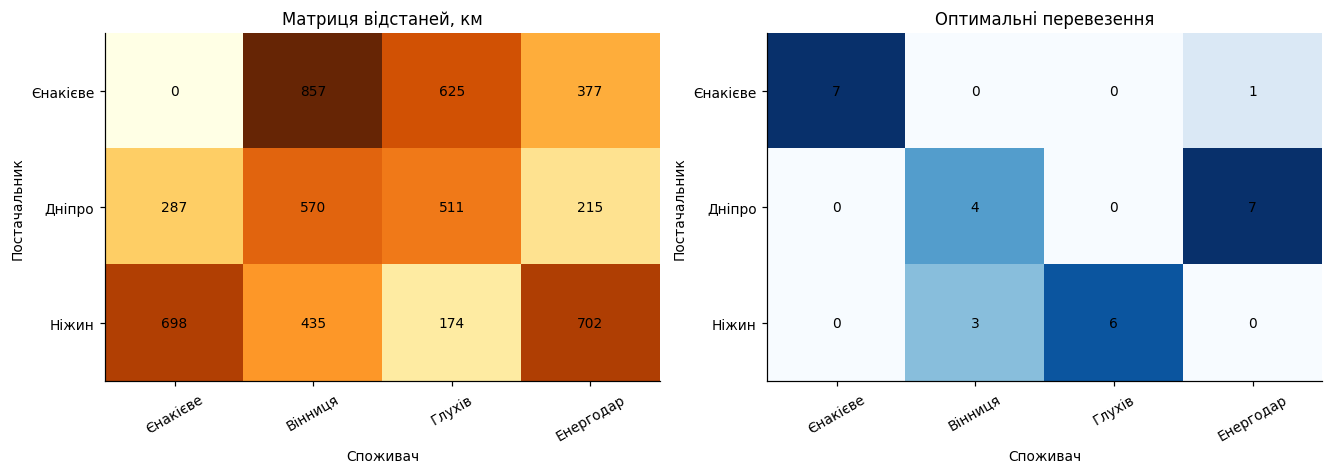

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')

matrices = [D, X_scipy]
titles = ['Матриця відстаней, км', 'Оптимальні перевезення']
cmaps = ['YlOrBr', 'Blues']

for ax, matrix, title, cmap in zip(axes, matrices, titles, cmaps):
    ax.imshow(matrix, cmap=cmap, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Споживач')
    ax.set_ylabel('Постачальник')
    ax.set_xticks(range(n), labels=споживачі, rotation=30)
    ax.set_yticks(range(m), labels=постачальники)

    for i in range(m):
        for j in range(n):
            ax.text(j, i, f'{matrix[i, j]:.0f}', ha='center', va='center')

plt.show()


**Висновок.** В оптимальному плані є 6 маршрутів із ненульовими перевезеннями. Найбільші обсяги йдуть з Дніпра до Енергодара та з Ніжина до Глухова.


---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [19]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі': 'текст, перероблено',
    'етап 2, побудова моделі в Excel': 'код, перевірено',
    'етап 3, код на Python': 'синтаксис',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю': 'текст, перероблено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача': 'код, перевірено'
}

ЩО_ПЕРЕВІРЕНО = (
    'Звірено оптимальний план і прибуток у Python та Excel. '
    'Перевірено тіньову ціну зміною запасу на одну одиницю, межу допустимого збільшення, '
    'допустимість округленого плану та цілочисельний оптимум. '
    'Для транспортної задачі порівняно результати двох способів розв’язання.'
)

ПІДТВЕРДЖУЮ = True


In [20]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Єдинець Євген
інструменти:                               ChatGPT
------------------------------------------------------------------------------
етап 1, формалізація моделі:               текст, перероблено
етап 2, побудова моделі в Excel:           код, перевірено
етап 3, код на Python:                     синтаксис
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             текст, перероблено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Звірено оптимальний план і прибуток у Python та Excel. Перевірено тіньову ціну зміною запасу на одну одиницю, межу допустимого збільшення, допустимість округленого плану та цілочисельний оптимум. Для транспортної задачі порівняно результати двох способів розв’язання.


---
# Крок 13. Фінальна самоперевірка

In [21]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
